In [8]:
import torch
import torch.nn as nn 
import torch.optim as optim 
from torch.utils.data import DataLoader, TensorDataset,random_split
import numpy as np
import random 
import matplotlib.pyplot as plt

In [ ]:
X=np.array([-2.0,-1.0,0.0,1.0,2.0,3.0,4.0], dtype=np.float32)
Y=np.array([-2.0,-1.0,0.0,1.0,2.0,3.0,4.0], dtype=np.float32)
np.random.seed(0)
a=np.random.rand( ) # 1.初始化参数
b=np.random.rand( )
print(f"Initial parameters: a={a}, b={b}")
lr=0.01 #学习率
n= len(X) #总量
for epoch in range(100):
    # 2.前向传播
    Y_pred=a*X+b
    # 3.计算损失
    loss=np.mean((Y_pred-Y)**2)
    # 4.反向传播
    grad_a=np.mean(2*(Y_pred-Y)*X)
    grad_b=np.mean(2*(Y_pred-Y))
    # 5.更新参数
    a -= lr * grad_a
    b -= lr * grad_b
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss}, Parameters: a={a}, b={b}")
# 6.预测
X_test=5.0
Y_test=a*X_test+b
print(f"真实值：{X_test}")
print(f"预测值：{Y_test}")

Initial parameters: a=0.5488135039273248, b=0.7151893663724195
Epoch 0, Loss: 0.8839744925498962, Parameters: a=0.5796284079551697, b=0.7099092602729797
Epoch 10, Loss: 0.4023558795452118, Parameters: a=0.7656778693199158, b=0.6383657455444336
Epoch 20, Loss: 0.26865023374557495, Parameters: a=0.8408185243606567, b=0.557116687297821
Epoch 30, Loss: 0.1944865733385086, Parameters: a=0.8773294687271118, b=0.48087382316589355
Epoch 40, Loss: 0.14261679351329803, Parameters: a=0.8993982672691345, b=0.41333121061325073
Epoch 50, Loss: 0.10478301346302032, Parameters: a=0.9152637720108032, b=0.35470589995384216
Epoch 60, Loss: 0.07700802385807037, Parameters: a=0.9278549551963806, b=0.3042077422142029
Epoch 70, Loss: 0.05659785494208336, Parameters: a=0.9383151531219482, b=0.26083678007125854
Epoch 80, Loss: 0.04159743711352348, Parameters: a=0.9471721649169922, b=0.22362865507602692
Epoch 90, Loss: 0.0305726807564497, Parameters: a=0.9547287225723267, b=0.19172142446041107
真实值：5.0
预测值：4.969

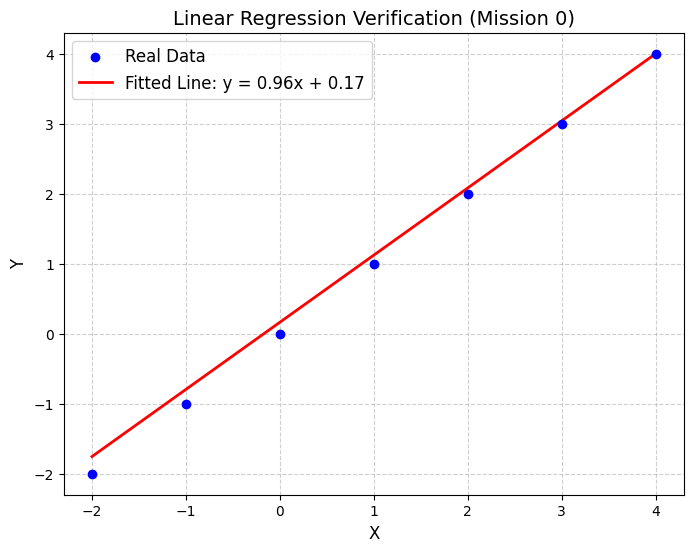

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X, Y, color='blue', label='Real Data', zorder=5)
Y_fitted = a * X + b 
plt.plot(X, Y_fitted, color='red', linewidth=2, label=f'Fitted Line: y = {a:.2f}x + {b:.2f}')
plt.title('Linear Regression Verification (Mission 0)', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.show()

在pytorch中，通常是直接使用包装好的函数，如loss.backward()用来直接计算梯度，同时，由于loss.backward()有累加效应，需要进行梯度归零
此时代码体现为
```py
loss.backward()
    with torch.no_grad(): #不影响自动微分模块
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        a.grad.zero_()
        b.grad.zero_()
```

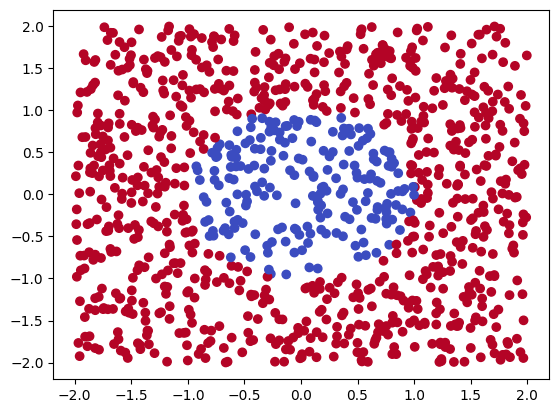

初始数据形状为: (10000, 3)


In [9]:
# utils/createDataAndPlot.py中的内容

NUM_OF_DATA = 10000


def tag_entry_circle(x, y):
    if x**2 + y**2 < 1:
        tag = 0
    else:
        tag = 1
    return tag


def tag_entry_triangle(x, y):
    x = x + 1
    y = y + 1
    if (
        (0 <= x <= 1.5)
        and (0 <= y <= 2)
        and (y >= (2 / 1.5) * x and y >= -(2 / 1.5) * (x - 1.5))
    ):
        tag = 0
    else:
        tag = 1
    return tag


def tag_entry_square(x, y):
    x = x + 1
    y = y + 1
    if (0 <= x <= 2) and (0 <= y <= 2):
        tag = 0
    else:
        tag = 1
    return tag


function = {
    "circle": tag_entry_circle,
    "triangle": tag_entry_triangle,
    "square": tag_entry_square,
}


def create_data(num_of_data=NUM_OF_DATA, mode="circle"):
    data = []
    for i in range(num_of_data):
        x = random.uniform(-2, 2)
        y = random.uniform(-2, 2)
        tag = function[mode](x, y)
        entry = [x, y, tag]
        data.append(entry)
    return np.array(data)


def plot_data(data1, data2, title):
    fig, ax = plt.subplots(1, 2)
    ax[0].scatter(data1[:, 0], data1[:, 1], c=data1[:, 2], cmap=plt.cm.coolwarm)
    ax[0].set_title(title + "1")
    ax[1].scatter(data2[:, 0], data2[:, 1], c=data2[:, 2], cmap=plt.cm.coolwarm)
    ax[1].set_title(title + "2")
    plt.show()

if __name__ == "__main__":
    data = create_data(1024, "circle")
    fig, ax = plt.subplots(1, 1)
    ax.scatter(data[:, 0], data[:, 1], c=data[:, 2], cmap=plt.cm.coolwarm)
    plt.savefig('data_circle.png')
    plt.show()
    plt.close()

# 测试
MODE = "circle"  
raw_data = create_data(num_of_data=NUM_OF_DATA, mode=MODE)
print(f"初始数据形状为: {raw_data.shape}")

In [10]:
# 1. 直接将你生成的 Numpy 数据转换为 PyTorch 的张量 (Tensor)
X = torch.FloatTensor(raw_data[:, :2]) # 提取前两列坐标点
y = torch.LongTensor(raw_data[:, 2])   # 提取最后一列标签

# 2. 划分 8:2 的训练集与测试集
full_dataset = TensorDataset(X, y)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# 3. 放入 PyTorch 数据加载器 (DataLoader)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# 4. 定义模型架构 (2 -> 4 -> 4 -> 2) 包含 Kaiming 初始化
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 4),
            nn.ReLU(),
            nn.Linear(4, 2)
        )
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.constant_(m.bias, 0.0)
                
    def forward(self, x):
        return self.net(x)

# 5. 实例化模型与优化器
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 6. 开始循环迭代训练
EPOCHS = 1000
print(f"正在基于你生成的数据进行 PyTorch 训练...")
for epoch in range(EPOCHS):
    model.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # 每 100 轮打印一次训练集准确率
    if (epoch + 1) % 100 == 0 or epoch == 0:
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == batch_y).sum().item()
                total += batch_y.size(0)
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {loss.item():.4f} | Train Acc: {(correct/total)*100:.2f}%")

print("模型训练完成！")

正在基于你生成的数据进行 PyTorch 训练...
Epoch [1/1000] | Train Loss: 0.2856 | Train Acc: 80.36%
Epoch [100/1000] | Train Loss: 0.0175 | Train Acc: 99.36%
Epoch [200/1000] | Train Loss: 0.0047 | Train Acc: 99.42%
Epoch [300/1000] | Train Loss: 0.0337 | Train Acc: 99.40%
Epoch [400/1000] | Train Loss: 0.0027 | Train Acc: 99.44%
Epoch [500/1000] | Train Loss: 0.0072 | Train Acc: 99.52%
Epoch [600/1000] | Train Loss: 0.0081 | Train Acc: 99.30%
Epoch [700/1000] | Train Loss: 0.0188 | Train Acc: 99.40%
Epoch [800/1000] | Train Loss: 0.0028 | Train Acc: 99.50%
Epoch [900/1000] | Train Loss: 0.0274 | Train Acc: 99.24%
Epoch [1000/1000] | Train Loss: 0.0106 | Train Acc: 99.52%
模型训练完成！


In [11]:
%matplotlib inline

model.eval()

# 1. 拿出测试集的数据在图上画散点
X_test = test_dataset.tensors[0].numpy()
y_test = test_dataset.tensors[1].numpy()

# 2. 生成密集的覆盖网格点 [-2, 2]，让模型预测背景颜色
x_min, x_max = -2.0, 2.0
y_min, y_max = -2.0, 2.0
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.FloatTensor(grid_points).to(device)

with torch.no_grad():
    outputs = model(grid_tensor)
    preds = torch.argmax(outputs, dim=1).cpu().numpy()
preds = preds.reshape(xx.shape)

# 3. 开始绘图
plt.figure(figsize=(8, 6))
# 绘制模型学到的背景决策边界
plt.contourf(xx, yy, preds, alpha=0.3, cmap=plt.cm.coolwarm)
# 叠加上测试集的真实散点
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, edgecolors='k', s=20)

plt.title(f"Decision Boundary - Mode: {MODE}")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

AttributeError: 'Subset' object has no attribute 'tensors'